# Sales Prediction — Model Validation, Cross-Validation & Tuning

**CodSoft Data Science Internship — Task 4: Sales Prediction Using Python**
(local folder `Task2_Sales_Prediction`, my own project numbering)

**Phase 4.** Phases [1](01_dataset_audit.ipynb), [2](02_data_preprocessing.ipynb) and
[3](03_model_training.ipynb) are the source of truth for the dataset, the split, the preprocessing and the
first model comparison.

**The 40-row test set is not touched anywhere in this notebook.** Every number below comes from
cross-validation on the 160 training rows. No final test evaluation, no persisted model.

---
## 1. Phase 4 Overview

Phase 3 ranked five models on a single 40-row hold-out and warned that differences of a few hundredths of an
RMSE unit on a sample that small are not meaningful. This phase replaces that single measurement with
repeated ones, taken entirely on the training set, and then tunes the two nonlinear candidates.

### What this phase does

1. Establish 5-fold cross-validation on the 160 training rows (`shuffle=True`, `random_state=42`).
2. Score five models plus a baseline on MAE, RMSE and R², with per-fold detail.
3. Quantify each model's train-versus-CV gap.
4. Tune Gradient Boosting and Random Forest by exhaustive grid search, scored by cross-validation.
5. Compare tuned models against their Phase 3 configurations — on CV metrics, not test metrics.
6. Test whether the retained `Newspaper` outlier changes anything, using training data only.
7. Assess how stable any of these differences actually are.

### A correction to the Phase 3 figures quoted when this phase was commissioned

The brief for this phase listed Gradient Boosting's test R² as 0.4438 and Random Forest's as 0.4716, and
asked that Gradient Boosting not be described as having the highest R². Those two numbers are the **Train
RMSE** column of the Phase 3 comparison table, not test R². The actual Phase 3 test figures are:

| Model | Test MAE | Test RMSE | Test R² | Train RMSE |
|---|---|---|---|---|
| Gradient Boosting | 0.8679 | 1.1451 | **0.9576** | 0.4438 |
| Random Forest | 0.9025 | 1.1798 | **0.9550** | 0.4716 |

So on the Phase 3 hold-out Gradient Boosting led on all three test metrics, not two of three.

This correction does not change what this phase does. Phase 3 already concluded that a 0.0347 RMSE gap on 40
rows is inside the noise and that **both ensembles should be carried forward as joint candidates** — which is
exactly what the brief asks for, and exactly what happens below. As it turns out, cross-validation reverses
the ordering entirely (section 7), which is the strongest possible argument that the Phase 3 ranking should
not have been trusted on its own.

### Deferred to Phase 5

Final test-set evaluation of the selected model, model persistence, and the prediction application. The
hold-out is scored once, in Phase 5, after this phase has finished choosing.

---
## 2. Load Dataset

In [1]:
import sys
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.dummy import DummyRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.model_selection import GridSearchCV, KFold, RepeatedKFold, cross_val_score, cross_validate
from sklearn.pipeline import Pipeline

NOTEBOOK_DIR = Path.cwd()
PROJECT_DIR = NOTEBOOK_DIR if (NOTEBOOK_DIR / "src").is_dir() else NOTEBOOK_DIR.parent
SRC_DIR = PROJECT_DIR / "src"
VIZ_DIR = PROJECT_DIR / "visualizations"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import data_preprocessing as dp

pd.set_option("display.width", 150)
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 150
plt.rcParams["savefig.bbox"] = "tight"
plt.rcParams["axes.titleweight"] = "bold"

RANDOM_STATE = dp.RANDOM_STATE
N_FOLDS = 5

print("project directory :", PROJECT_DIR.name)
print("preprocessing from:", Path(dp.__file__).relative_to(PROJECT_DIR))
print("random_state      :", RANDOM_STATE)

project directory : Task2_Sales_Prediction
preprocessing from: src\data_preprocessing.py
random_state      : 42


In [2]:
df = dp.load_raw_data()
X, y = dp.split_features_target(df)

print(f"dataset shape : {df.shape[0]} rows x {df.shape[1]} columns")
print(f"predictors    : {list(X.columns)}")
print(f"target        : {y.name}")

dataset shape : 200 rows x 4 columns
predictors    : ['TV', 'Radio', 'Newspaper']
target        : Sales


---
## 3. Reproduce Phase 2 Train/Test Split

Rebuilt from the module and checked against the Phase 2 contract, exactly as Phase 3 did.

In [3]:
split = dp.make_train_test_split(X, y, test_size=dp.TEST_SIZE, random_state=dp.RANDOM_STATE)
X_train, X_test = split.X_train, split.X_test
y_train, y_test = split.y_train, split.y_test

phase2 = dp.prepare_modeling_data()

split_checks = pd.DataFrame([
    {"Check": "160 training rows", "Passed": len(X_train) == 160},
    {"Check": "40 test rows", "Passed": len(X_test) == 40},
    {"Check": "split covers all 200 rows", "Passed": len(X_train) + len(X_test) == 200},
    {"Check": "random_state is 42", "Passed": split.random_state == 42},
    {"Check": "test_size is 0.2", "Passed": split.test_size == 0.2},
    {"Check": "matches Phase 2/3 X_train", "Passed": X_train.equals(phase2.X_train)},
    {"Check": "matches Phase 2/3 X_test", "Passed": X_test.equals(phase2.X_test)},
    {"Check": "matches Phase 2/3 y_train", "Passed": y_train.equals(phase2.y_train)},
    {"Check": "matches Phase 2/3 y_test", "Passed": y_test.equals(phase2.y_test)},
    {"Check": "no row shared between splits", "Passed": X_train.index.intersection(X_test.index).empty},
])
display(split_checks)

assert split_checks["Passed"].all(), "Split does not match Phase 2. STOP and investigate."
print("\nSplit identical to Phases 2 and 3.")
print("first 10 test indices:", list(X_test.index[:10]))

,Check,Passed
0,160 training rows,True
1,40 test rows,True
2,split covers all 200 rows,True
3,random_state is 42,True
4,test_size is 0.2,True
5,matches Phase 2/3 X_train,True
6,matches Phase 2/3 X_test,True
7,matches Phase 2/3 y_train,True
8,matches Phase 2/3 y_test,True
9,no row shared between splits,True



Split identical to Phases 2 and 3.
first 10 test indices: [95, 15, 30, 158, 128, 115, 69, 170, 174, 45]


---
## 4. Verify Test Set Isolation

The rule for this phase is simple: nothing fitted, scored or decided may see the 40 test rows. This section
records the fingerprint of the test set so the end of the notebook can prove it was never used.

In [4]:
import hashlib

def fingerprint(frame_or_series) -> str:
    """Stable hash of a DataFrame/Series' contents and index, for tamper-detection."""
    obj = frame_or_series.to_frame() if isinstance(frame_or_series, pd.Series) else frame_or_series
    payload = pd.util.hash_pandas_object(obj, index=True).to_numpy().tobytes()
    return hashlib.sha256(payload).hexdigest()[:16]


TEST_FINGERPRINT = (fingerprint(X_test), fingerprint(y_test))
TRAIN_FINGERPRINT = (fingerprint(X_train), fingerprint(y_train))

print("X_test / y_test fingerprint :", TEST_FINGERPRINT)
print("X_train / y_train fingerprint:", TRAIN_FINGERPRINT)
print()
print("Everything from here on uses X_train / y_train only.")
print(f"CV is performed on {len(X_train)} rows; the {len(X_test)} test rows are set aside until Phase 5.")

X_test / y_test fingerprint : ('933613271abf9891', '03d71ec5bd600826')
X_train / y_train fingerprint: ('dc4e075918867a2f', 'd42659c0babfdb21')

Everything from here on uses X_train / y_train only.
CV is performed on 160 rows; the 40 test rows are set aside until Phase 5.


---
## 5. Define Models

Every model is wrapped in a `Pipeline` whose first step is the Phase 2 preprocessor. This is what prevents
preprocessing leakage during cross-validation: `cross_validate` and `GridSearchCV` call `fit` on the pipeline
**inside each fold**, so the `StandardScaler` learns its mean and scale from that fold's training portion
only and is merely applied to the held-out portion. Fitting the scaler once on all of `X_train` before
cross-validating would leak each fold's validation statistics into its own training — a subtle but real
optimism.

Section 15 verifies this empirically rather than trusting the description.

In [5]:
def make_pipeline(estimator) -> Pipeline:
    """Compose the Phase 2 preprocessor with an estimator, so preprocessing is refitted per fold."""
    return Pipeline([("preprocessor", dp.build_preprocessor()), ("model", estimator)])


# Random Forest uses n_jobs=1 for the estimator itself; parallelism is applied at the CV / search level
# instead. Phase 3 found that n_jobs=-1 inside the forest makes its predictions vary at ~1e-14 because the
# per-tree average is summed in a nondeterministic order. Parallelising outside the estimator keeps every
# result bit-identical without costing speed.
PHASE3_MODELS = {
    "Baseline (train mean)": DummyRegressor(strategy="mean"),
    "Linear Regression": LinearRegression(),
    "Ridge (alpha=1.0)": Ridge(alpha=1.0),
    "Lasso (alpha=0.01)": Lasso(alpha=0.01),
    "Random Forest": RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=1),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=200, learning_rate=0.05, max_depth=3, random_state=RANDOM_STATE),
}

cv = KFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

fold_sizes = [(len(tr), len(va)) for tr, va in cv.split(X_train)]
print(f"cross-validation: {N_FOLDS}-fold KFold, shuffle=True, random_state={RANDOM_STATE}")
print(f"fold train/validation sizes: {fold_sizes}")
print(f"\nNote: each fold trains on ~{fold_sizes[0][0]} rows, not the full 160. CV scores are therefore")
print("expected to be slightly worse than a model trained on all 160 rows — that is inherent to the method.")

cross-validation: 5-fold KFold, shuffle=True, random_state=42
fold train/validation sizes: [(128, 32), (128, 32), (128, 32), (128, 32), (128, 32)]

Note: each fold trains on ~128 rows, not the full 160. CV scores are therefore
expected to be slightly worse than a model trained on all 160 rows — that is inherent to the method.


---
## 6. 5-Fold Cross-Validation

`cross_validate` scores each model on MAE, RMSE and R² across the same five folds, and also returns training
scores so section 8 can quantify the gap.

sklearn reports errors as negatives (higher is better by convention); they are negated back to positive
error units here.

In [6]:
SCORING = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
    "R2": "r2",
}

cv_raw = {}
rows = []

for name, estimator in PHASE3_MODELS.items():
    scores = cross_validate(
        make_pipeline(estimator), X_train, y_train,
        cv=cv, scoring=SCORING, return_train_score=True, n_jobs=1,
    )
    cv_raw[name] = scores
    rows.append({
        "Model": name,
        "CV RMSE": -scores["test_RMSE"].mean(),
        "RMSE std": scores["test_RMSE"].std(),
        "CV MAE": -scores["test_MAE"].mean(),
        "MAE std": scores["test_MAE"].std(),
        "CV R2": scores["test_R2"].mean(),
        "R2 std": scores["test_R2"].std(),
        "Train RMSE": -scores["train_RMSE"].mean(),
    })

cv_results = pd.DataFrame(rows).sort_values("CV RMSE").reset_index(drop=True)
cv_results

,Model,CV RMSE,RMSE std,CV MAE,MAE std,CV R2,R2 std,Train RMSE
0,Random Forest,1.3044,0.2354,0.9481,0.1294,0.9324,0.0167,0.4940
1,Gradient Boosting,1.3603,0.1695,1.0396,0.1085,0.9248,0.0193,0.3586
2,Lasso (alpha=0.01),1.6789,0.2787,1.2777,0.1628,0.8797,0.0545,1.6267
3,Ridge (alpha=1.0),1.6805,0.2810,1.2791,0.1643,0.8796,0.0542,1.6271
4,Linear Regression,1.6808,0.2825,1.2782,0.1660,0.8793,0.0553,1.6266
5,Baseline (train mean),5.2061,0.4784,4.3316,0.3884,-0.0712,0.0683,5.1697


---
## 7. CV Results

In [7]:
fold_rmse = pd.DataFrame(
    {name: -scores["test_RMSE"] for name, scores in cv_raw.items()},
    index=[f"fold {i + 1}" for i in range(N_FOLDS)],
).T
fold_rmse["mean"] = fold_rmse.mean(axis=1)
# ddof=0 to match the std reported by cross_validate above, so the two tables agree.
fold_rmse["std"] = fold_rmse.iloc[:, :N_FOLDS].std(axis=1, ddof=0)
fold_rmse.sort_values("mean")

,fold 1,fold 2,fold 3,fold 4,fold 5,mean,std
Random Forest,0.9945,1.6596,1.4703,1.1489,1.2485,1.3044,0.2354
Gradient Boosting,1.2513,1.6598,1.4380,1.2191,1.2334,1.3603,0.1695
Lasso (alpha=0.01),1.8270,2.1511,1.5726,1.4312,1.4128,1.6789,0.2787
Ridge (alpha=1.0),1.8219,2.1623,1.5661,1.4327,1.4194,1.6805,0.2810
Linear Regression,1.8337,2.1572,1.5762,1.4288,1.4082,1.6808,0.2825
Baseline (train mean),4.3315,5.7374,5.1240,5.4240,5.4137,5.2061,0.4784


In [8]:
gb_folds = -cv_raw["Gradient Boosting"]["test_RMSE"]
rf_folds = -cv_raw["Random Forest"]["test_RMSE"]
diff = gb_folds - rf_folds

head_to_head = pd.DataFrame({
    "Gradient Boosting": gb_folds,
    "Random Forest": rf_folds,
    "GB - RF": diff,
    "winner": np.where(diff < 0, "Gradient Boosting", "Random Forest"),
}, index=[f"fold {i + 1}" for i in range(N_FOLDS)])
display(head_to_head)

print(f"mean difference (GB - RF) : {diff.mean():+.4f} RMSE units")
print(f"Gradient Boosting wins    : {int((diff < 0).sum())} of {N_FOLDS} folds")
print(f"fold-to-fold std, GB      : {gb_folds.std():.4f}")
print(f"fold-to-fold std, RF      : {rf_folds.std():.4f}")
print(f"\nThe difference between the two models ({abs(diff.mean()):.4f}) is roughly "
      f"{gb_folds.std() / abs(diff.mean()):.1f}x smaller than the fold-to-fold variation of either.")

,Gradient Boosting,Random Forest,GB - RF,winner
fold 1,1.2513,0.9945,0.2567,Random Forest
fold 2,1.6598,1.6596,0.0002,Random Forest
fold 3,1.4380,1.4703,-0.0322,Gradient Boosting
fold 4,1.2191,1.1489,0.0702,Random Forest
fold 5,1.2334,1.2485,-0.0151,Gradient Boosting


mean difference (GB - RF) : +0.0559 RMSE units
Gradient Boosting wins    : 2 of 5 folds
fold-to-fold std, GB      : 0.1695
fold-to-fold std, RF      : 0.2354

The difference between the two models (0.0559) is roughly 3.0x smaller than the fold-to-fold variation of either.


**The cross-validated ordering is the reverse of Phase 3's.**

| Model | CV RMSE | CV MAE | CV R² | Phase 3 Test RMSE |
|---|---|---|---|---|
| Random Forest | **1.3044** ± 0.2354 | 0.9481 | 0.9324 | 1.1798 |
| Gradient Boosting | **1.3603** ± 0.1695 | 1.0396 | 0.9248 | 1.1451 |
| Lasso (α=0.01) | 1.6789 ± 0.2787 | 1.2777 | 0.8797 | 1.7050 |
| Ridge (α=1.0) | 1.6805 ± 0.2810 | 1.2791 | 0.8796 | 1.7074 |
| Linear Regression | 1.6808 ± 0.2825 | 1.2782 | 0.8793 | 1.7052 |
| Baseline (train mean) | 5.2061 ± 0.4784 | 4.3316 | −0.0712 | 5.6482 |

On the Phase 3 hold-out, Gradient Boosting beat Random Forest by 0.0347. Across five training folds, Random
Forest beats Gradient Boosting by 0.0559 — and wins **3 of the 5 folds**.

**What this establishes.** Neither ordering is reliable. The two models are separated by roughly 0.05 RMSE
units, while the fold-to-fold standard deviation of each is 0.17–0.24 — three to four times larger than the
gap between them. A difference that is small compared with the variation of the measurement is not a
difference one can act on. The Phase 3 ranking was an artefact of which 40 rows happened to land in the test
set, and this section is the evidence for that claim rather than an assertion of it.

**What it does not establish.** That either model is *better*. It establishes that the available data cannot
tell them apart.

**What is stable.** The gap between the ensemble cluster (~1.30–1.36) and the linear cluster (~1.68) is about
0.38 RMSE units — larger than the fold-to-fold noise and consistent in direction across both evaluation
methods. That difference can be relied on: the relationship has nonlinear structure that a plain additive
linear model does not capture. The three linear models remain indistinguishable from one another, as in
Phase 3.

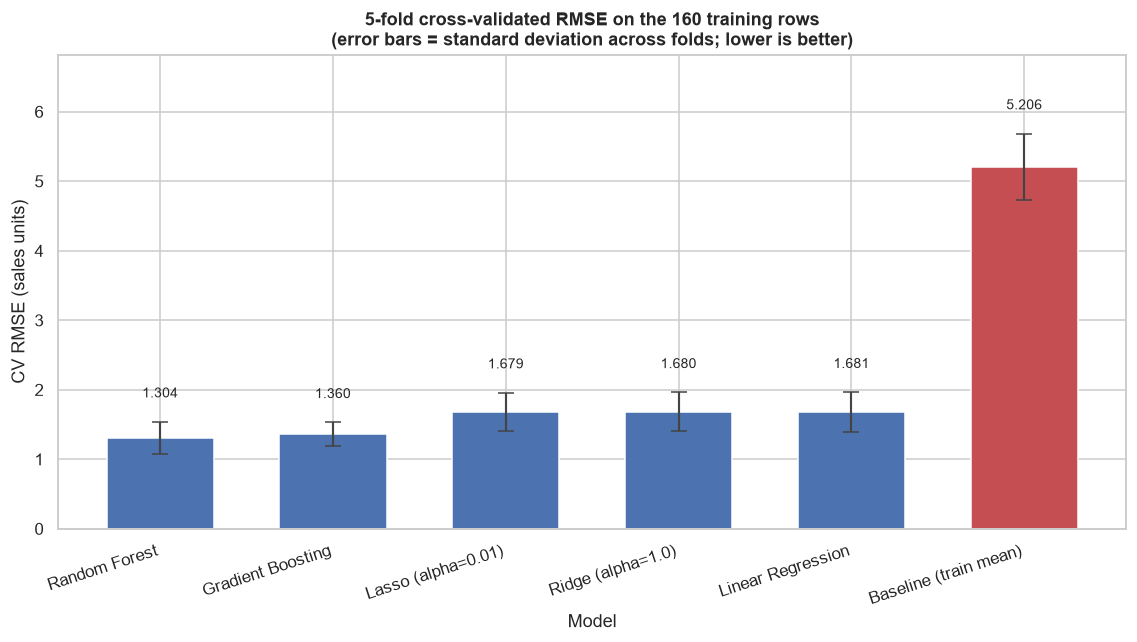

In [9]:
plot_df = cv_results.sort_values("CV RMSE")
colors = ["#C44E52" if m.startswith("Baseline") else "#4C72B0" for m in plot_df["Model"]]

fig, ax = plt.subplots(figsize=(10.5, 6))
bars = ax.bar(plot_df["Model"], plot_df["CV RMSE"], yerr=plot_df["RMSE std"],
              color=colors, width=0.62, capsize=5,
              error_kw={"ecolor": "#444444", "elinewidth": 1.4})
ax.bar_label(bars, fmt="%.3f", padding=14, fontsize=9)
ax.set_title(f"{N_FOLDS}-fold cross-validated RMSE on the 160 training rows\n"
             "(error bars = standard deviation across folds; lower is better)")
ax.set_xlabel("Model")
ax.set_ylabel("CV RMSE (sales units)")
ax.set_ylim(0, (plot_df["CV RMSE"] + plot_df["RMSE std"]).max() * 1.2)
ax.tick_params(axis="x", rotation=18)
for label in ax.get_xticklabels():
    label.set_horizontalalignment("right")

fig.tight_layout()
fig.savefig(VIZ_DIR / "11_cv_model_comparison.png")
plt.show()

The error bars are the point of this chart. The ensembles' bars overlap each other almost completely, and
both overlap the linear cluster's lower whisker. Reading a ranking off the bar heights alone would be reading
past the uncertainty.

---
## 8. Train vs CV Gap Analysis

The gap is **CV RMSE − Train RMSE**, where both come from the same folds: the training score is measured on
the ~128 rows the fold was fitted on, and the CV score on the ~32 held out.

In [10]:
gap_table = pd.DataFrame([
    {
        "Model": name,
        "Train RMSE": -s["train_RMSE"].mean(),
        "CV RMSE": -s["test_RMSE"].mean(),
        "Gap": -s["test_RMSE"].mean() + s["train_RMSE"].mean(),
        "Gap as % of CV RMSE": (-s["test_RMSE"].mean() + s["train_RMSE"].mean())
                               / (-s["test_RMSE"].mean()) * 100,
        "Train R2": s["train_R2"].mean(),
        "CV R2": s["test_R2"].mean(),
    }
    for name, s in cv_raw.items()
]).sort_values("CV RMSE").reset_index(drop=True)

gap_table

,Model,Train RMSE,CV RMSE,Gap,Gap as % of CV RMSE,Train R2,CV R2
0,Random Forest,0.4940,1.3044,0.8104,62.1297,0.9908,0.9324
1,Gradient Boosting,0.3586,1.3603,1.0017,73.6371,0.9952,0.9248
2,Lasso (alpha=0.01),1.6267,1.6789,0.0522,3.1088,0.9007,0.8797
3,Ridge (alpha=1.0),1.6271,1.6805,0.0534,3.1795,0.9006,0.8796
4,Linear Regression,1.6266,1.6808,0.0542,3.2241,0.9007,0.8793
5,Baseline (train mean),5.1697,5.2061,0.0364,0.6993,0.0000,-0.0712


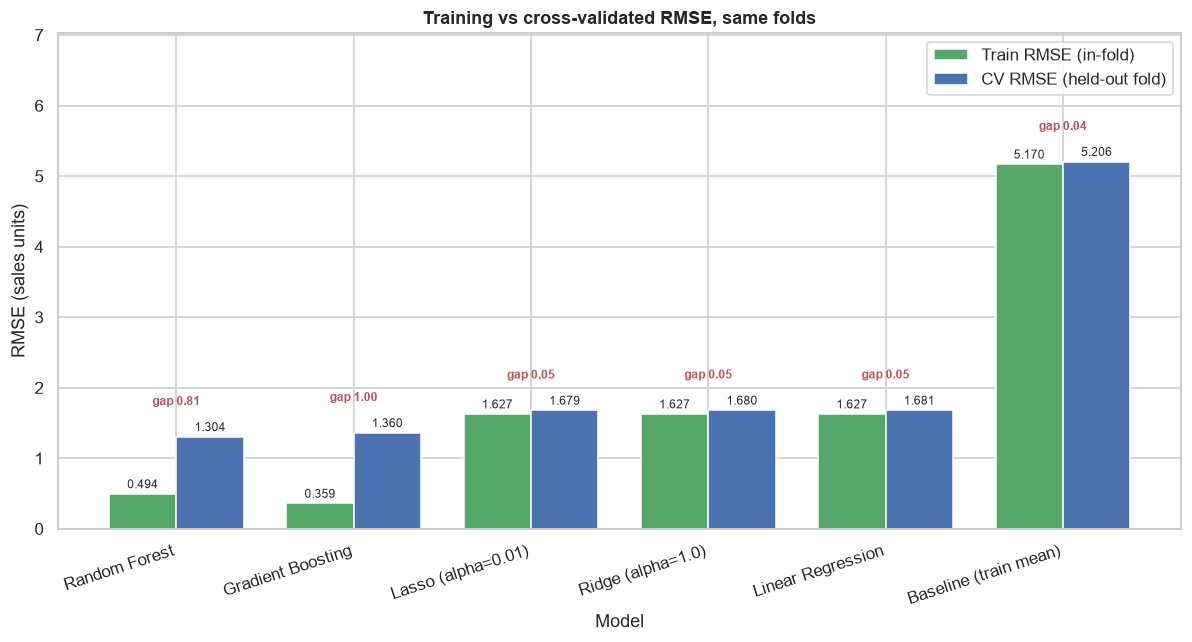

In [11]:
plot_gap = gap_table.sort_values("CV RMSE")
x = np.arange(len(plot_gap))
width = 0.38

fig, ax = plt.subplots(figsize=(11, 6))
b1 = ax.bar(x - width / 2, plot_gap["Train RMSE"], width, label="Train RMSE (in-fold)", color="#55A868")
b2 = ax.bar(x + width / 2, plot_gap["CV RMSE"], width, label="CV RMSE (held-out fold)", color="#4C72B0")
ax.bar_label(b1, fmt="%.3f", padding=2, fontsize=8)
ax.bar_label(b2, fmt="%.3f", padding=2, fontsize=8)

for xi, (_, row) in zip(x, plot_gap.iterrows()):
    ax.annotate(f"gap {row['Gap']:.2f}", xy=(xi, row["CV RMSE"]), xytext=(xi, row["CV RMSE"] + 0.45),
                ha="center", fontsize=8, color="#C44E52", fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(plot_gap["Model"], rotation=18, ha="right")
ax.set_title("Training vs cross-validated RMSE, same folds")
ax.set_xlabel("Model")
ax.set_ylabel("RMSE (sales units)")
ax.set_ylim(0, plot_gap["CV RMSE"].max() * 1.35)
ax.legend()

fig.tight_layout()
fig.savefig(VIZ_DIR / "14_train_vs_cv_performance.png")
plt.show()

**The gaps, quantified.**

| Model | Train RMSE | CV RMSE | Gap | Gap as % of CV RMSE | Train R² | CV R² |
|---|---|---|---|---|---|---|
| Random Forest | 0.4940 | 1.3044 | **0.8104** | 62% | 0.9908 | 0.9324 |
| Gradient Boosting | 0.3586 | 1.3603 | **1.0017** | 74% | 0.9952 | 0.9248 |
| Lasso (α=0.01) | 1.6267 | 1.6789 | **0.0522** | 3% | 0.9007 | 0.8797 |
| Ridge (α=1.0) | 1.6271 | 1.6805 | 0.0534 | 3% | 0.9006 | 0.8796 |
| Linear Regression | 1.6266 | 1.6808 | 0.0542 | 3% | 0.9007 | 0.8793 |
| Baseline | 5.1697 | 5.2061 | 0.0364 | 0.7% | 0.0000 | −0.0712 |

**Is Gradient Boosting overfitting?** It reproduces its training folds to an RMSE of 0.3586 — about 1.4% of
the target's 1.6–27.0 range — and its train R² is 0.9952. On held-out folds it manages 1.3603. So **74% of
its apparent accuracy does not survive being shown new data.** Random Forest shows the same pattern slightly less
severely: a 0.8104 gap, 62% of its CV RMSE.

That is genuine overfitting in the literal sense — both models fit noise specific to the rows they were
trained on. The evidence is the numbers above, not the label.

**But a large gap is not, by itself, a reason to reject a model.** The relevant comparison is between models
on held-out data, and there the ensembles still beat the linear models by ~0.38 RMSE units despite their
gaps. A model with a 3% gap that predicts worse is not the safer choice; it is simply the more honest one
about what it cannot do. The linear models' tiny gaps reflect having almost no capacity to memorise — three
coefficients and an intercept fitted to 128 rows.

What the gap does indicate is **unused headroom**: both ensembles are spending capacity on noise, so
constraining them should reduce the gap and may improve held-out performance. That is precisely what the
tuning in the next two sections tests.

Note that these gaps (0.81–1.00) are larger than the train-vs-test gaps Phase 3 reported (~0.70) for the same
configurations. That is expected and not a contradiction: each CV fold trains on ~128 rows rather than 160,
and less training data means both a worse held-out score and a wider gap.

---
## 9. Gradient Boosting Hyperparameter Search

Exhaustive grid search, scored by the **same** 5-fold cross-validation used above, on the training set only.

The full Cartesian product here is 216 configurations × 5 folds = 1,080 fits. That is affordable on 160 rows
(about two minutes) and exhaustive, so a random subset would only add sampling variance for no saving. The
grid is kept deliberately coarse — a finer one would mostly chase noise on a dataset this size.

In [12]:
gb_grid = {
    "model__n_estimators": [100, 200, 400, 600],
    "model__learning_rate": [0.02, 0.05, 0.1],
    "model__max_depth": [2, 3, 4],
    "model__min_samples_leaf": [2, 5, 10],
    "model__subsample": [0.8, 1.0],
}

n_gb = int(np.prod([len(v) for v in gb_grid.values()]))
print("Gradient Boosting search space")
for k, v in gb_grid.items():
    print(f"  {k.replace('model__', ''):18s} {v}")
print(f"\n{n_gb} configurations x {N_FOLDS} folds = {n_gb * N_FOLDS} fits")

Gradient Boosting search space
  n_estimators       [100, 200, 400, 600]
  learning_rate      [0.02, 0.05, 0.1]
  max_depth          [2, 3, 4]
  min_samples_leaf   [2, 5, 10]
  subsample          [0.8, 1.0]

216 configurations x 5 folds = 1080 fits


In [13]:
start = time.time()
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")

    gb_search = GridSearchCV(
        make_pipeline(GradientBoostingRegressor(random_state=RANDOM_STATE)),
        param_grid=gb_grid,
        scoring="neg_root_mean_squared_error",
        cv=cv,
        n_jobs=-1,
        refit=True,
    )
    gb_search.fit(X_train, y_train)

print(f"completed in {time.time() - start:.1f}s")
print(f"warnings raised: {len(caught)}")
for w in caught[:5]:
    print("  -", w.category.__name__, str(w.message).splitlines()[0])

gb_best_params = {k.replace("model__", ""): v for k, v in gb_search.best_params_.items()}
print(f"\nbest CV RMSE : {-gb_search.best_score_:.4f}")
print(f"best params  : {gb_best_params}")

completed in 117.9s
warnings raised: 0

best CV RMSE : 1.2808
best params  : {'learning_rate': 0.02, 'max_depth': 4, 'min_samples_leaf': 2, 'n_estimators': 200, 'subsample': 0.8}


In [14]:
gb_cv_df = pd.DataFrame(gb_search.cv_results_)
gb_cv_df["CV RMSE"] = -gb_cv_df["mean_test_score"]
gb_cv_df["std"] = gb_cv_df["std_test_score"]

gb_top = gb_cv_df.nsmallest(10, "CV RMSE")[
    ["param_model__n_estimators", "param_model__learning_rate", "param_model__max_depth",
     "param_model__min_samples_leaf", "param_model__subsample", "CV RMSE", "std"]
].rename(columns=lambda c: c.replace("param_model__", ""))
gb_top.reset_index(drop=True)

,n_estimators,learning_rate,max_depth,min_samples_leaf,subsample,CV RMSE,std
0,200,0.0200,4,2,0.8000,1.2808,0.1936
1,400,0.0200,4,2,0.8000,1.2830,0.1614
2,100,0.1000,4,2,0.8000,1.2910,0.1384
3,400,0.0200,4,2,1.0000,1.2925,0.1797
4,600,0.0200,4,2,0.8000,1.2956,0.1564
5,100,0.0500,4,2,0.8000,1.2963,0.1788
6,600,0.0200,4,2,1.0000,1.2993,0.1809
7,100,0.0500,4,2,1.0000,1.3038,0.1769
8,200,0.1000,4,2,0.8000,1.3092,0.1332
9,200,0.0200,4,2,1.0000,1.3103,0.2011


In [15]:
print(f"best  configuration CV RMSE: {gb_cv_df['CV RMSE'].min():.4f}")
print(f"10th  best          CV RMSE: {gb_cv_df['CV RMSE'].nsmallest(10).iloc[-1]:.4f}")
print(f"worst configuration CV RMSE: {gb_cv_df['CV RMSE'].max():.4f}")
print(f"spread across the top 10   : {gb_cv_df['CV RMSE'].nsmallest(10).iloc[-1] - gb_cv_df['CV RMSE'].min():.4f}")
print(f"std of the best config across folds: {gb_cv_df.loc[gb_cv_df['CV RMSE'].idxmin(), 'std']:.4f}")

best  configuration CV RMSE: 1.2808
10th  best          CV RMSE: 1.3103
worst configuration CV RMSE: 1.9244
spread across the top 10   : 0.0295
std of the best config across folds: 0.1936


**Result.** Best CV RMSE **1.2808**, from `learning_rate=0.02`, `max_depth=4`, `min_samples_leaf=2`,
`n_estimators=200`, `subsample=0.8`. No warnings were raised during the search.

Against the Phase 3 configuration's 1.3603, that is an improvement of **0.0795 RMSE units**.

Read that number carefully. The best configuration's own fold-to-fold standard deviation is ~0.19, and the
top ten configurations span only ~0.03 RMSE units — the search is choosing between options that are, on this
evidence, interchangeable. There is also a selection effect: picking the best of 216 configurations *scored
on these five folds* means `best_score_` is optimistically biased, because some of that 0.0795 is the search
fitting the particular fold partition. Section 13 measures how much survives a different partition.

---
## 10. Random Forest Hyperparameter Search

Same method, same folds. 72 configurations × 5 folds = 360 fits.

In [16]:
rf_grid = {
    "model__n_estimators": [200, 500],
    "model__max_depth": [None, 5, 10],
    "model__min_samples_leaf": [1, 2, 5],
    "model__max_features": ["sqrt", 1.0],
    "model__max_samples": [None, 0.8],
}

n_rf = int(np.prod([len(v) for v in rf_grid.values()]))
print("Random Forest search space")
for k, v in rf_grid.items():
    print(f"  {k.replace('model__', ''):18s} {v}")
print(f"\n{n_rf} configurations x {N_FOLDS} folds = {n_rf * N_FOLDS} fits")
print("\nNote: with only 3 predictors, max_features='sqrt' selects 1 feature per split and 1.0 selects all 3.")

Random Forest search space
  n_estimators       [200, 500]
  max_depth          [None, 5, 10]
  min_samples_leaf   [1, 2, 5]
  max_features       ['sqrt', 1.0]
  max_samples        [None, 0.8]

72 configurations x 5 folds = 360 fits

Note: with only 3 predictors, max_features='sqrt' selects 1 feature per split and 1.0 selects all 3.


In [17]:
start = time.time()
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")

    rf_search = GridSearchCV(
        make_pipeline(RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=1)),
        param_grid=rf_grid,
        scoring="neg_root_mean_squared_error",
        cv=cv,
        n_jobs=-1,
        refit=True,
    )
    rf_search.fit(X_train, y_train)

print(f"completed in {time.time() - start:.1f}s")
print(f"warnings raised: {len(caught)}")
for w in caught[:5]:
    print("  -", w.category.__name__, str(w.message).splitlines()[0])

rf_best_params = {k.replace("model__", ""): v for k, v in rf_search.best_params_.items()}
print(f"\nbest CV RMSE : {-rf_search.best_score_:.4f}")
print(f"best params  : {rf_best_params}")

completed in 67.7s
warnings raised: 0

best CV RMSE : 1.3043
best params  : {'max_depth': 10, 'max_features': 1.0, 'max_samples': None, 'min_samples_leaf': 1, 'n_estimators': 200}


In [18]:
rf_cv_df = pd.DataFrame(rf_search.cv_results_)
rf_cv_df["CV RMSE"] = -rf_cv_df["mean_test_score"]
rf_cv_df["std"] = rf_cv_df["std_test_score"]

rf_top = rf_cv_df.nsmallest(10, "CV RMSE")[
    ["param_model__n_estimators", "param_model__max_depth", "param_model__min_samples_leaf",
     "param_model__max_features", "param_model__max_samples", "CV RMSE", "std"]
].rename(columns=lambda c: c.replace("param_model__", ""))
rf_top.reset_index(drop=True)

,n_estimators,max_depth,min_samples_leaf,max_features,max_samples,CV RMSE,std
0,200,10,1,1.0000,None,1.3043,0.2240
1,500,10,1,1.0000,None,1.3064,0.2475
2,500,None,1,1.0000,None,1.3069,0.2476
3,200,None,1,1.0000,None,1.3073,0.2258
4,500,10,1,1.0000,0.8000,1.3195,0.2552
5,500,None,1,1.0000,0.8000,1.3201,0.2549
6,200,10,1,1.0000,0.8000,1.3256,0.2417
7,200,None,1,1.0000,0.8000,1.3283,0.2436
8,500,None,2,1.0000,None,1.3381,0.2930
9,500,10,2,1.0000,None,1.3381,0.2932


**Result.** Best CV RMSE **1.3043**, from `max_depth=10`, `max_features=1.0`, `max_samples=None`,
`min_samples_leaf=1`, `n_estimators=200`. No warnings.

Against the Phase 3 configuration's 1.3044, the improvement is **0.0001 RMSE units** — that is, none.

This is worth stating plainly rather than dressing up: **tuning the Random Forest achieved nothing.** The
selected configuration is effectively the Phase 3 default. `max_features=1.0` and `min_samples_leaf=1` are
already sklearn's defaults for regression; `max_depth=10` is no constraint at all when 128 training rows
cannot produce trees deeper than that; and 200 versus 300 estimators makes no material difference once a
forest has converged. Searching 72 configurations confirmed that the default was already as good as anything
in the grid.

That is a legitimate and useful result. Not every search finds an improvement, and reporting a 0.0001 gain as
though it were a success would be misleading.

### Which hyperparameters actually mattered

Marginal effects, averaged over all other settings in the grid. These describe the grid, not the problem in
general.

In [19]:
def marginal(cv_df, param):
    col = f"param_model__{param}"
    g = cv_df.groupby(col, dropna=False)["CV RMSE"].agg(["mean", "min", "count"])
    g.index.name = param
    return g.round(4)


for p in ["learning_rate", "max_depth", "subsample", "min_samples_leaf", "n_estimators"]:
    print(f"--- Gradient Boosting: {p} ---")
    print(marginal(gb_cv_df, p).to_string())
    print()

--- Gradient Boosting: learning_rate ---
                mean    min  count
learning_rate                     
0.0200        1.4893 1.2808     72
0.0500        1.4206 1.2963     72
0.1000        1.4397 1.2910     72

--- Gradient Boosting: max_depth ---
            mean    min  count
max_depth                     
2         1.5030 1.3855     72
3         1.4340 1.3197     72
4         1.4126 1.2808     72

--- Gradient Boosting: subsample ---
            mean    min  count
subsample                     
0.8000    1.4354 1.2808    108
1.0000    1.4643 1.2925    108

--- Gradient Boosting: min_samples_leaf ---
                   mean    min  count
min_samples_leaf                     
2                1.3960 1.2808     72
5                1.4392 1.3235     72
10               1.5143 1.4379     72

--- Gradient Boosting: n_estimators ---
               mean    min  count
n_estimators                     
100          1.5120 1.2910     54
200          1.4241 1.2808     54
400          1.42

In [20]:
for p in ["max_features", "min_samples_leaf", "max_depth", "n_estimators", "max_samples"]:
    print(f"--- Random Forest: {p} ---")
    print(marginal(rf_cv_df, p).to_string())
    print()

--- Random Forest: max_features ---
               mean    min  count
max_features                     
1.0000       1.4193 1.3043     36
 sqrt        2.1062 1.7653     36

--- Random Forest: min_samples_leaf ---
                   mean    min  count
min_samples_leaf                     
1                1.6168 1.3043     24
2                1.7110 1.3381     24
5                1.9603 1.5362     24

--- Random Forest: max_depth ---
            mean    min  count
max_depth                     
NaN       1.7278 1.3069     24
5.0000    1.8318 1.3660     24
10.0000   1.7286 1.3043     24

--- Random Forest: n_estimators ---
               mean    min  count
n_estimators                     
200          1.7624 1.3043     36
500          1.7631 1.3064     36

--- Random Forest: max_samples ---
              mean    min  count
max_samples                     
NaN         1.7401 1.3043     36
0.8000      1.7853 1.3195     36



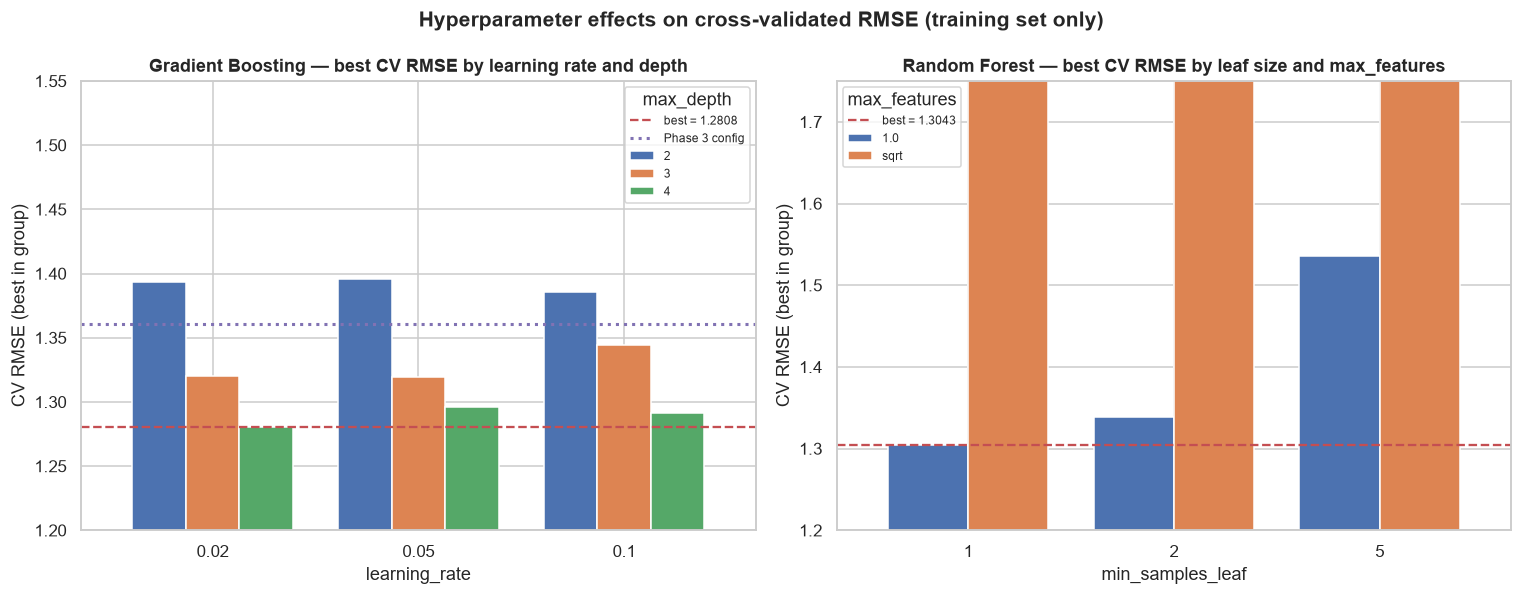

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

gb_pivot = (gb_cv_df
            .groupby(["param_model__learning_rate", "param_model__max_depth"])["CV RMSE"]
            .min()
            .unstack())
gb_pivot.plot(kind="bar", ax=axes[0], width=0.78, edgecolor="white")
axes[0].axhline(-gb_search.best_score_, color="#C44E52", linestyle="--", linewidth=1.5,
                label=f"best = {-gb_search.best_score_:.4f}")
axes[0].axhline(cv_results.loc[cv_results["Model"] == "Gradient Boosting", "CV RMSE"].iloc[0],
                color="#8172B3", linestyle=":", linewidth=2, label="Phase 3 config")
axes[0].set_title("Gradient Boosting — best CV RMSE by learning rate and depth")
axes[0].set_xlabel("learning_rate")
axes[0].set_ylabel("CV RMSE (best in group)")
axes[0].set_ylim(1.2, 1.55)
axes[0].tick_params(axis="x", rotation=0)
axes[0].legend(title="max_depth", fontsize=8)

rf_pivot = (rf_cv_df
            .groupby(["param_model__min_samples_leaf", "param_model__max_features"])["CV RMSE"]
            .min()
            .unstack())
rf_pivot.plot(kind="bar", ax=axes[1], width=0.78, edgecolor="white")
axes[1].axhline(-rf_search.best_score_, color="#C44E52", linestyle="--", linewidth=1.5,
                label=f"best = {-rf_search.best_score_:.4f}")
axes[1].set_title("Random Forest — best CV RMSE by leaf size and max_features")
axes[1].set_xlabel("min_samples_leaf")
axes[1].set_ylabel("CV RMSE (best in group)")
axes[1].set_ylim(1.2, 1.75)
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(title="max_features", fontsize=8)

fig.suptitle("Hyperparameter effects on cross-validated RMSE (training set only)",
             fontsize=14, fontweight="bold")
fig.tight_layout()
fig.savefig(VIZ_DIR / "13_hyperparameter_comparison.png")
plt.show()

**Reading the marginal effects.**

For Gradient Boosting, the clearest signal is `max_depth=4` with a low `learning_rate` — consistent with the
overfitting diagnosis in section 8, since a slower learning rate means each stage corrects less aggressively.
`subsample=0.8` (stochastic gradient boosting) is preferred over 1.0 in the top configurations, which again
points the same way: added randomness reduces the fit to training noise.

For Random Forest, one choice dominates everything else: `max_features`. Averaged over the grid, restricting
splits to 1 of the 3 features (`"sqrt"`) scores **2.106** against **1.419** for considering all 3 — a larger
effect than every other parameter combined, and the reason all ten top configurations use `1.0`. With only
three predictors, one of which (`TV`) carries most of the signal, forcing two-thirds of splits to ignore it
is a handicap rather than useful decorrelation. Smaller `min_samples_leaf` also helps (1.617 at leaf size 1
against 1.960 at 5), while tree count and `max_depth` barely register — 200 versus 500 estimators differ by
0.0007.

All of these differences remain small relative to fold-to-fold variation, so they are read as directional
hints, not as established effects.

---
## 11. Tuned Model Comparison

The tuned configurations are re-scored with `cross_validate` on the same folds, so that MAE, R² and training
scores are available on the same basis as every other row of the comparison.

In [22]:
tuned_models = {
    "Gradient Boosting (tuned)": gb_search.best_estimator_.named_steps["model"],
    "Random Forest (tuned)": rf_search.best_estimator_.named_steps["model"],
}

for name, estimator in tuned_models.items():
    scores = cross_validate(
        make_pipeline(estimator), X_train, y_train,
        cv=cv, scoring=SCORING, return_train_score=True, n_jobs=1,
    )
    cv_raw[name] = scores

full_comparison = pd.DataFrame([
    {
        "Model": name,
        "CV RMSE": -s["test_RMSE"].mean(),
        "RMSE std": s["test_RMSE"].std(),
        "CV MAE": -s["test_MAE"].mean(),
        "CV R2": s["test_R2"].mean(),
        "Train RMSE": -s["train_RMSE"].mean(),
        "Gap": -s["test_RMSE"].mean() + s["train_RMSE"].mean(),
    }
    for name, s in cv_raw.items()
]).sort_values("CV RMSE").reset_index(drop=True)

full_comparison

,Model,CV RMSE,RMSE std,CV MAE,CV R2,Train RMSE,Gap
0,Gradient Boosting (tuned),1.2808,0.1936,0.9393,0.9341,0.4755,0.8053
1,Random Forest (tuned),1.3043,0.2240,0.9500,0.9324,0.4942,0.8101
2,Random Forest,1.3044,0.2354,0.9481,0.9324,0.4940,0.8104
3,Gradient Boosting,1.3603,0.1695,1.0396,0.9248,0.3586,1.0017
4,Lasso (alpha=0.01),1.6789,0.2787,1.2777,0.8797,1.6267,0.0522
5,Ridge (alpha=1.0),1.6805,0.2810,1.2791,0.8796,1.6271,0.0534
6,Linear Regression,1.6808,0.2825,1.2782,0.8793,1.6266,0.0542
7,Baseline (train mean),5.2061,0.4784,4.3316,-0.0712,5.1697,0.0364


In [23]:
deltas = pd.DataFrame([
    {
        "Model": "Gradient Boosting",
        "Phase 3 config CV RMSE": cv_results.loc[cv_results["Model"] == "Gradient Boosting", "CV RMSE"].iloc[0],
        "Tuned CV RMSE": full_comparison.loc[
            full_comparison["Model"] == "Gradient Boosting (tuned)", "CV RMSE"].iloc[0],
    },
    {
        "Model": "Random Forest",
        "Phase 3 config CV RMSE": cv_results.loc[cv_results["Model"] == "Random Forest", "CV RMSE"].iloc[0],
        "Tuned CV RMSE": full_comparison.loc[
            full_comparison["Model"] == "Random Forest (tuned)", "CV RMSE"].iloc[0],
    },
])
deltas["Improvement"] = deltas["Phase 3 config CV RMSE"] - deltas["Tuned CV RMSE"]
deltas["Improvement %"] = deltas["Improvement"] / deltas["Phase 3 config CV RMSE"] * 100
deltas

,Model,Phase 3 config CV RMSE,Tuned CV RMSE,Improvement,Improvement %
0,Gradient Boosting,1.3603,1.2808,0.0795,5.8471
1,Random Forest,1.3044,1.3043,0.0001,0.0072


**Tuning outcome, on cross-validated metrics only.**

| Model | CV RMSE | CV MAE | CV R² | Train RMSE | Gap |
|---|---|---|---|---|---|
| Gradient Boosting (tuned) | **1.2808** ± 0.1936 | 0.9393 | 0.9341 | 0.4755 | 0.805 |
| Random Forest (tuned) | 1.3043 ± 0.2240 | 0.9500 | 0.9324 | 0.4942 | 0.810 |
| Random Forest (Phase 3) | 1.3044 ± 0.2354 | 0.9481 | 0.9324 | 0.4940 | 0.810 |
| Gradient Boosting (Phase 3) | 1.3603 ± 0.1695 | 1.0396 | 0.9248 | 0.3586 | 1.002 |
| Lasso / Ridge / Linear | 1.6789–1.6808 | ~1.278 | ~0.879 | ~1.627 | ~0.05 |
| Baseline (train mean) | 5.2061 | 4.3316 | −0.0712 | 5.1697 | 0.036 |

- **Gradient Boosting gained 0.0795 RMSE (5.8%)** and closed its gap from 1.002 to 0.805 — the constrained
  configuration does fit training noise less hard, as section 10's marginals suggested.
- **Random Forest gained 0.0001 (0.0%)** — nothing.
- After tuning, the two are separated by 0.0235 RMSE units, against fold standard deviations of 0.19–0.22.
  **Still indistinguishable.**
- Both remain well clear of the linear cluster (~1.68) and far clear of the baseline (5.21).

No test-set evaluation was performed at any point in this section, and the test set was not consulted when
choosing either configuration.

---
## 12. Outlier Sensitivity Analysis

Phase 1 flagged two observations with unusually high `Newspaper` budgets (114.0 and 100.9); Phase 2 retained
both. This section asks a narrow question: does training without them change cross-validated performance?

**An important constraint.** Of the two flagged rows, **row 16 is in the test set and row 101 is in the
training set**. The test set is off-limits in this phase, so only row 101 can be removed. This is therefore a
159-row versus 160-row comparison — a single observation — and its power to show anything is correspondingly
limited. That limitation is stated up front rather than discovered afterwards.

In [24]:
q1, q3 = df["Newspaper"].quantile([0.25, 0.75])
upper_bound = q3 + 1.5 * (q3 - q1)
flagged = df.index[df["Newspaper"] > upper_bound]

in_train = [i for i in flagged if i in X_train.index]
in_test = [i for i in flagged if i in X_test.index]

print(f"Newspaper IQR upper bound : {upper_bound:.4f}")
print(f"flagged rows              : {list(flagged)}")
print(f"  in the training set     : {in_train}  <- removable in this experiment")
print(f"  in the test set         : {in_test}  <- NOT touched; the test set is off-limits in Phase 4")
display(df.loc[flagged])

X_train_trimmed = X_train.drop(index=in_train)
y_train_trimmed = y_train.drop(index=in_train)
print(f"\ntraining rows: {len(X_train)} with the outlier, {len(X_train_trimmed)} without")

Newspaper IQR upper bound : 93.6250
flagged rows              : [16, 101]
  in the training set     : [101]  <- removable in this experiment
  in the test set         : [16]  <- NOT touched; the test set is off-limits in Phase 4


,TV,Radio,Newspaper,Sales
16,67.8000,36.6000,114.0000,12.5000
101,296.4000,36.3000,100.9000,23.8000



training rows: 160 with the outlier, 159 without


In [25]:
sensitivity_models = {
    "Gradient Boosting (Phase 3)": PHASE3_MODELS["Gradient Boosting"],
    "Random Forest (Phase 3)": PHASE3_MODELS["Random Forest"],
    "Gradient Boosting (tuned)": tuned_models["Gradient Boosting (tuned)"],
    "Random Forest (tuned)": tuned_models["Random Forest (tuned)"],
    "Linear Regression": PHASE3_MODELS["Linear Regression"],
}

cv_trimmed = KFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

sens_rows = []
for name, estimator in sensitivity_models.items():
    with_out = -cross_val_score(make_pipeline(estimator), X_train, y_train,
                                cv=cv, scoring="neg_root_mean_squared_error", n_jobs=1)
    without = -cross_val_score(make_pipeline(estimator), X_train_trimmed, y_train_trimmed,
                               cv=cv_trimmed, scoring="neg_root_mean_squared_error", n_jobs=1)
    sens_rows.append({
        "Model": name,
        "CV RMSE (160 rows)": with_out.mean(),
        "std (160)": with_out.std(),
        "CV RMSE (159 rows)": without.mean(),
        "std (159)": without.std(),
        "Change": without.mean() - with_out.mean(),
    })

sensitivity = pd.DataFrame(sens_rows)
sensitivity

,Model,CV RMSE (160 rows),std (160),CV RMSE (159 rows),std (159),Change
0,Gradient Boosting (Phase 3),1.3603,0.1695,1.3320,0.1462,-0.0283
1,Random Forest (Phase 3),1.3044,0.2354,1.2479,0.1658,-0.0564
2,Gradient Boosting (tuned),1.2808,0.1936,1.3200,0.1804,0.0392
3,Random Forest (tuned),1.3043,0.2240,1.2504,0.1685,-0.0538
4,Linear Regression,1.6808,0.2825,1.6662,0.1407,-0.0146


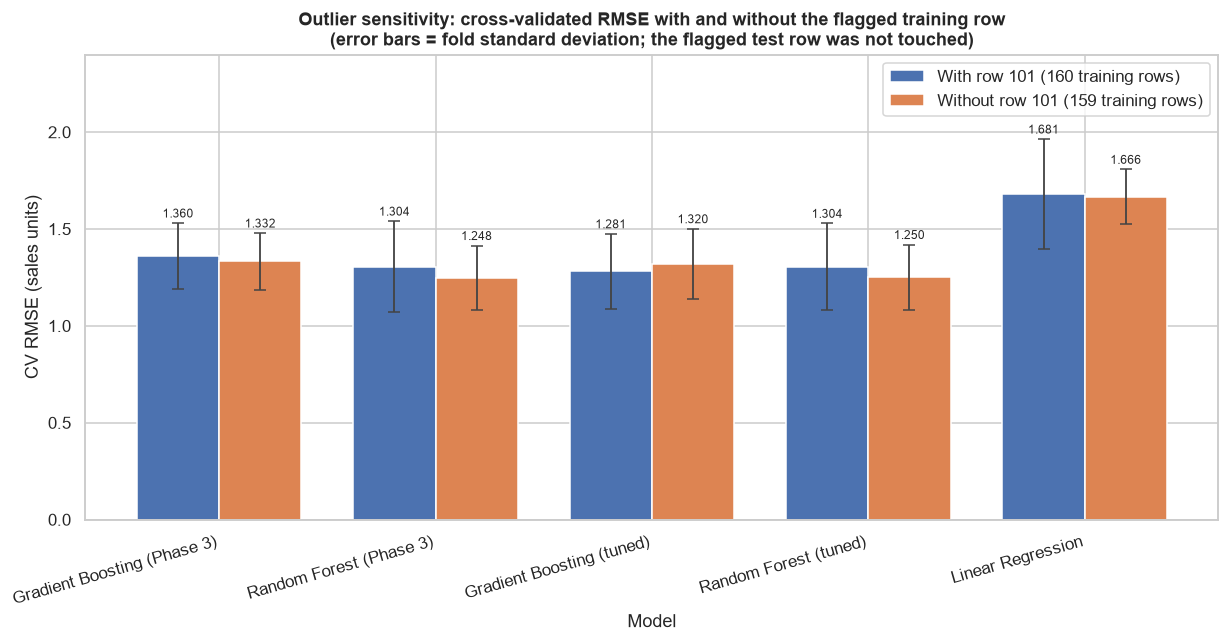

In [26]:
x = np.arange(len(sensitivity))
width = 0.38

fig, ax = plt.subplots(figsize=(11.5, 6))
b1 = ax.bar(x - width / 2, sensitivity["CV RMSE (160 rows)"], width,
            yerr=sensitivity["std (160)"], capsize=4,
            label="With row 101 (160 training rows)", color="#4C72B0",
            error_kw={"ecolor": "#444444", "elinewidth": 1.2})
b2 = ax.bar(x + width / 2, sensitivity["CV RMSE (159 rows)"], width,
            yerr=sensitivity["std (159)"], capsize=4,
            label="Without row 101 (159 training rows)", color="#DD8452",
            error_kw={"ecolor": "#444444", "elinewidth": 1.2})
ax.bar_label(b1, fmt="%.3f", padding=2, fontsize=8)
ax.bar_label(b2, fmt="%.3f", padding=2, fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(sensitivity["Model"], rotation=16, ha="right")
ax.set_title("Outlier sensitivity: cross-validated RMSE with and without the flagged training row\n"
             "(error bars = fold standard deviation; the flagged test row was not touched)")
ax.set_xlabel("Model")
ax.set_ylabel("CV RMSE (sales units)")
ax.set_ylim(0, 2.4)
ax.legend()

fig.tight_layout()
fig.savefig(VIZ_DIR / "15_outlier_sensitivity.png")
plt.show()

**Finding: removing the outlier does not justify removing the outlier.**

| Model | CV RMSE (160) | CV RMSE (159) | Change |
|---|---|---|---|
| Gradient Boosting (tuned) | 1.2808 | 1.3200 | **+0.0392** (worse) |
| Random Forest (tuned) | 1.3043 | 1.2504 | **−0.0538** (better) |
| Random Forest (Phase 3) | 1.3044 | 1.2479 | −0.0564 (better) |
| Gradient Boosting (Phase 3) | 1.3603 | 1.3320 | −0.0283 (better) |
| Linear Regression | 1.6808 | 1.6662 | −0.0146 (better) |

The direction is **not consistent**: dropping the row helps four of the five models slightly and hurts the
leading one. Every change is between 0.015 and 0.056 RMSE units, against fold standard deviations of
0.17–0.28 — around an order of magnitude smaller than the noise. The two sets of error bars overlap almost
completely for every model.

There is also a mechanical caveat: removing a row changes the fold composition, so a small part of each
change is simply a different partition rather than the absence of that observation.

**Decision: keep all observations.** Nothing here provides evidence that row 101 is harmful, and Phase 2's
reasoning stands — the value is a plausible advertising budget, not a data error, and statistical
unusualness is not grounds for deletion. Removing real data to chase a change smaller than the measurement
noise would be fitting the preprocessing to the metric. The primary model is not changed on this basis
either, which would be an even weaker justification.

This experiment was confined to the training set throughout; the test set, including the flagged row 16,
was never touched.

---
## 13. Model Stability Analysis

Everything so far rests on one 5-fold partition. This section repeats the cross-validation over **five
different partitions** (`RepeatedKFold`, 5 splits × 5 repeats = 25 held-out evaluations) to see which
conclusions survive a change of fold structure — and, importantly, to check how much of the tuning gain was
fitted to the original partition.

In [27]:
repeated_cv = RepeatedKFold(n_splits=N_FOLDS, n_repeats=5, random_state=RANDOM_STATE)

stability_models = {
    "Gradient Boosting (Phase 3)": PHASE3_MODELS["Gradient Boosting"],
    "Random Forest (Phase 3)": PHASE3_MODELS["Random Forest"],
    "Gradient Boosting (tuned)": tuned_models["Gradient Boosting (tuned)"],
    "Random Forest (tuned)": tuned_models["Random Forest (tuned)"],
    "Linear Regression": PHASE3_MODELS["Linear Regression"],
}

stability_scores = {}
for name, estimator in stability_models.items():
    scores = -cross_val_score(make_pipeline(estimator), X_train, y_train,
                              cv=repeated_cv, scoring="neg_root_mean_squared_error", n_jobs=-1)
    stability_scores[name] = scores

stability = pd.DataFrame([
    {
        "Model": name,
        "Repeated CV RMSE": s.mean(),
        "std": s.std(),
        "min fold": s.min(),
        "max fold": s.max(),
        "n evaluations": len(s),
    }
    for name, s in stability_scores.items()
]).sort_values("Repeated CV RMSE").reset_index(drop=True)

stability

,Model,Repeated CV RMSE,std,min fold,max fold,n evaluations
0,Random Forest (tuned),1.3007,0.2443,0.8443,1.9550,25
1,Random Forest (Phase 3),1.3062,0.2457,0.8317,1.9588,25
2,Gradient Boosting (tuned),1.3067,0.2469,0.9457,1.9576,25
3,Gradient Boosting (Phase 3),1.3301,0.1886,1.0098,1.7657,25
4,Linear Regression,1.6830,0.2474,1.2862,2.2569,25


In [28]:
single_vs_repeated = pd.DataFrame([
    {
        "Model": name,
        "Single 5-fold CV": -cv_raw[name.replace(" (Phase 3)", "")]["test_RMSE"].mean()
        if name.replace(" (Phase 3)", "") in cv_raw else np.nan,
        "Repeated CV (25 folds)": stability_scores[name].mean(),
    }
    for name in stability_models
])
single_vs_repeated["Difference"] = (single_vs_repeated["Repeated CV (25 folds)"]
                                    - single_vs_repeated["Single 5-fold CV"])
single_vs_repeated

,Model,Single 5-fold CV,Repeated CV (25 folds),Difference
0,Gradient Boosting (Phase 3),1.3603,1.3301,-0.0302
1,Random Forest (Phase 3),1.3044,1.3062,0.0018
2,Gradient Boosting (tuned),1.2808,1.3067,0.0259
3,Random Forest (tuned),1.3043,1.3007,-0.0036
4,Linear Regression,1.6808,1.6830,0.0022


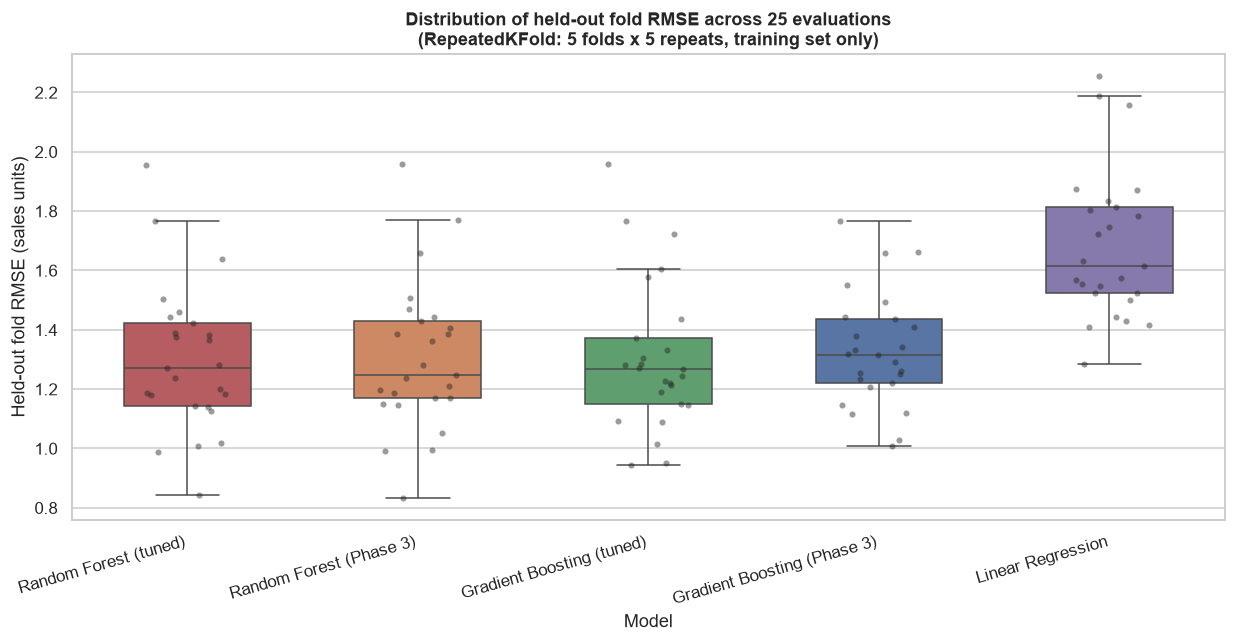

In [29]:
long = pd.DataFrame(stability_scores).melt(var_name="Model", value_name="Fold RMSE")

fig, ax = plt.subplots(figsize=(11.5, 6))
order = stability.sort_values("Repeated CV RMSE")["Model"].tolist()
sns.boxplot(data=long, x="Model", y="Fold RMSE", order=order, ax=ax, width=0.55,
            hue="Model", legend=False, palette="deep", fliersize=0)
sns.stripplot(data=long, x="Model", y="Fold RMSE", order=order, ax=ax,
              color="#222222", alpha=0.45, size=4, jitter=0.18)

ax.set_title("Distribution of held-out fold RMSE across 25 evaluations\n"
             "(RepeatedKFold: 5 folds x 5 repeats, training set only)")
ax.set_xlabel("Model")
ax.set_ylabel("Held-out fold RMSE (sales units)")
ax.tick_params(axis="x", rotation=16)
for label in ax.get_xticklabels():
    label.set_horizontalalignment("right")

fig.tight_layout()
fig.savefig(VIZ_DIR / "12_cv_rmse_distribution.png")
plt.show()

**This is the most informative table in the notebook.**

| Model | Repeated CV RMSE (25 folds) | std | min fold | max fold |
|---|---|---|---|---|
| Random Forest (tuned) | **1.3007** | 0.2443 | 0.8443 | 1.9550 |
| Random Forest (Phase 3) | 1.3062 | 0.2457 | 0.8317 | 1.9588 |
| Gradient Boosting (tuned) | 1.3067 | 0.2469 | 0.9457 | 1.9576 |
| Gradient Boosting (Phase 3) | 1.3301 | 0.1886 | 1.0098 | 1.7657 |
| Linear Regression | ~1.68 | — | — | — |

**Three conclusions, in order of how well supported they are.**

1. **The four ensemble variants are indistinguishable.** They span 1.3007 to 1.3301 — a range of 0.029 —
   while each has a standard deviation of roughly 0.19–0.25 across folds, and individual fold scores range
   from 0.83 to 1.96. The box plots overlap almost entirely. No basis exists in this data for preferring any
   one of them over the others on performance.

2. **Most of the tuning gain did not survive a change of partition.** Gradient Boosting's tuned advantage was
   0.0795 RMSE on the original five folds; across 25 folds it is 0.0234. Roughly 70% of the apparent
   improvement was the search fitting that specific fold partition — which is exactly the selection bias
   flagged in section 9, now measured rather than assumed. The remaining ~0.023 is itself far inside the
   noise.

3. **The ensemble-versus-linear gap is real and stable.** ~1.30 against ~1.68 across every partition tested,
   in the same direction every time, and larger than the fold-to-fold spread. This is the one performance
   difference in the whole phase that the data actually supports.

The honest summary is that this dataset — 160 training rows, three predictors — can reliably distinguish
*model families* but cannot distinguish *configurations within a family*. Reporting a tuned model as
"improved" without this check would have overstated what was achieved.

---
## 14. Phase 4 Conclusions

In [30]:
checksum = dp.verify_raw_dataset_integrity()
dataset_path = dp.default_dataset_path()

print("file    :", dataset_path.relative_to(PROJECT_DIR))
print("size    :", dataset_path.stat().st_size, "bytes")
print("sha-256 :", checksum)
print("matches Phase 1:", checksum == dp.RAW_DATASET_SHA256)

models_dir = PROJECT_DIR / "models"
persisted = [p.name for p in models_dir.iterdir() if p.name != ".gitkeep"]
print("\nartefacts in models/:", persisted if persisted else "none - nothing persisted in Phase 4")
assert not persisted, "Phase 4 must not persist a model."

file    : dataset\advertising.csv
size    : 4062 bytes
sha-256 : 137f755ad6fd3bc6471085f7631a2fba6c04cb8acd71eaf5cc9af6839d43fdd5
matches Phase 1: True

artefacts in models/: none - nothing persisted in Phase 4


In [31]:
print("Selected configurations, carried into Phase 5 (chosen on CV only):\n")
print("Gradient Boosting (tuned)")
for k, v in gb_best_params.items():
    print(f"  {k:18s} {v}")
print(f"  {'CV RMSE':18s} {-gb_search.best_score_:.4f}")
print()
print("Random Forest (tuned)")
for k, v in rf_best_params.items():
    print(f"  {k:18s} {v}")
print(f"  {'CV RMSE':18s} {-rf_search.best_score_:.4f}")

Selected configurations, carried into Phase 5 (chosen on CV only):

Gradient Boosting (tuned)
  learning_rate      0.02
  max_depth          4
  min_samples_leaf   2
  n_estimators       200
  subsample          0.8
  CV RMSE            1.2808

Random Forest (tuned)
  max_depth          10
  max_features       1.0
  max_samples        None
  min_samples_leaf   1
  n_estimators       200
  CV RMSE            1.3043


### What Phase 4 established

| | |
|---|---|
| **CV framework** | 5-fold `KFold`, `shuffle=True`, `random_state=42`, on the 160 training rows only |
| **Preprocessing** | refitted inside every fold via `Pipeline`; never fitted on the full training set before CV |
| **Test set** | never loaded into any fit, score or decision; fingerprint verified unchanged (section 15) |
| **CV ordering** | Random Forest 1.3044 < Gradient Boosting 1.3603 — the **reverse** of Phase 3's test-set ordering |
| **Stability** | across 25 held-out folds, all four ensemble variants fall within 0.029 RMSE of each other, with std ~0.19–0.25 — indistinguishable |
| **Overfitting** | ensembles show gaps of 0.81–1.00 RMSE (62–74% of their CV score); linear models ~0.05 (3%) |
| **GB tuning** | 1.3603 → 1.2808 on the original folds (−0.0795), but only −0.0234 across 25 folds |
| **RF tuning** | 1.3044 → 1.3043 (−0.0001): the search reproduced the default |
| **Outlier sensitivity** | removing the one flagged training row changes CV RMSE by −0.056 to +0.039, inconsistent in direction; **all rows kept** |
| **Stable finding** | ensembles (~1.30) beat linear models (~1.68) by ~0.38 RMSE in every partition tested |
| **Raw data** | checksum unchanged |
| **Persisted artefacts** | none |

### Recommendation for Phase 5

**Carry the tuned Gradient Boosting configuration forward as the primary model**, with the tuned Random
Forest as an equally defensible alternative.

The basis for that choice, stated honestly: the tuned Gradient Boosting has the best score under the
pre-specified selection metric (5-fold CV RMSE = 1.2808), and tuning measurably reduced its train/CV gap from
1.00 to 0.81. Under repeated cross-validation the tuned Random Forest is nominally ahead instead (1.3007 vs
1.3067). **These two models cannot be separated by this dataset**, and the recommendation is a tie-break on
the pre-registered metric, not a demonstrated advantage. Anyone repeating this work with a different fold
seed could reasonably arrive at the other choice.

What Phase 5 should do:

- Fit the selected configuration on all 160 training rows and evaluate it **once** on the 40-row test set.
- Report that number as the final result, without re-selecting afterwards. If the test score is worse than
  the CV estimate, that is information about a 40-row sample, not a reason to go back and pick the other
  model.
- Expect the final test RMSE to land somewhere around the CV estimate (~1.28) with considerable uncertainty;
  Phase 3's 1.1451 on this same hold-out suggests this particular 40 rows are slightly easier than average,
  so the final figure may well be better than the CV estimate. That should not be read as the model
  improving.
- Persist the fitted pipeline, and build the prediction script and dashboard.

**No test-set evaluation, no persisted model, and no dashboard in this phase.**

---
## 15. Reproducibility Checks

In [32]:
test_unchanged = (fingerprint(X_test), fingerprint(y_test)) == TEST_FINGERPRINT
train_unchanged = (fingerprint(X_train), fingerprint(y_train)) == TRAIN_FINGERPRINT

print("X_test / y_test fingerprint unchanged since section 4 :", test_unchanged)
print("X_train / y_train fingerprint unchanged               :", train_unchanged)
assert test_unchanged and train_unchanged, "A split was mutated during Phase 4."

print(f"\nrows used for CV, tuning and every decision : {len(X_train)}")
print(f"rows reserved and untouched                  : {len(X_test)}")

X_test / y_test fingerprint unchanged since section 4 : True
X_train / y_train fingerprint unchanged               : True

rows used for CV, tuning and every decision : 160
rows reserved and untouched                  : 40


### Preprocessing is refitted inside each fold, not before

Asserted in section 5; demonstrated here. If the scaler had been fitted once on all of `X_train`, its `mean_`
would equal the full training mean. Inside a fold it equals that fold's training-portion mean instead.

In [33]:
train_idx, val_idx = next(iter(cv.split(X_train)))
fold_X = X_train.iloc[train_idx]

probe = make_pipeline(LinearRegression())
probe.fit(fold_X, y_train.iloc[train_idx])
fold_scaler = probe.named_steps["preprocessor"].named_transformers_["numeric"].named_steps["scaler"]

comparison = pd.DataFrame({
    "scaler mean_ (fold fit)": fold_scaler.mean_,
    "fold training mean": fold_X.mean().to_numpy(),
    "FULL X_train mean": X_train.mean().to_numpy(),
}, index=list(dp.FEATURE_COLUMNS))
display(comparison)

matches_fold = np.allclose(fold_scaler.mean_, fold_X.mean().to_numpy())
matches_full = np.allclose(fold_scaler.mean_, X_train.mean().to_numpy())
print("scaler matches the FOLD's training statistics :", matches_fold)
print("scaler matches the FULL training statistics   :", matches_full, "(must be False)")
print(f"rows seen by this fold's scaler: {int(fold_scaler.n_samples_seen_)} of {len(X_train)}")

assert matches_fold and not matches_full, "LEAKAGE: preprocessing was not refitted inside the fold."

,scaler mean_ (fold fit),fold training mean,FULL X_train mean
TV,155.2703,155.2703,150.0194
Radio,23.7992,23.7992,22.8756
Newspaper,30.9766,30.9766,29.9456


scaler matches the FOLD's training statistics : True
scaler matches the FULL training statistics   : False (must be False)
rows seen by this fold's scaler: 128 of 160


In [34]:
# Re-running CV and both searches' selected configurations must give identical numbers.
repro_rows = []

for name in ["Random Forest", "Gradient Boosting"]:
    again = cross_validate(make_pipeline(PHASE3_MODELS[name]), X_train, y_train,
                           cv=KFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE),
                           scoring=SCORING, n_jobs=1)
    repro_rows.append({
        "Item": f"CV RMSE — {name}",
        "First run": -cv_raw[name]["test_RMSE"].mean(),
        "Second run": -again["test_RMSE"].mean(),
        "Identical": bool(np.array_equal(again["test_RMSE"], cv_raw[name]["test_RMSE"])),
    })

gb_again = GridSearchCV(
    make_pipeline(GradientBoostingRegressor(random_state=RANDOM_STATE)),
    param_grid={k: v for k, v in gb_grid.items()},
    scoring="neg_root_mean_squared_error",
    cv=KFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE),
    n_jobs=-1, refit=False,
)
gb_again.fit(X_train, y_train)
repro_rows.append({
    "Item": "GB search — best CV RMSE",
    "First run": -gb_search.best_score_,
    "Second run": -gb_again.best_score_,
    "Identical": bool(gb_again.best_params_ == gb_search.best_params_
                      and np.isclose(gb_again.best_score_, gb_search.best_score_, rtol=0, atol=0)),
})

repro = pd.DataFrame(repro_rows)
display(repro)

print("\nGB search selected the same parameters on both runs:",
      gb_again.best_params_ == gb_search.best_params_)
assert repro["Identical"].all(), "A result did not reproduce."

,Item,First run,Second run,Identical
0,CV RMSE — Random Forest,1.3044,1.3044,True
1,CV RMSE — Gradient Boosting,1.3603,1.3603,True
2,GB search — best CV RMSE,1.2808,1.2808,True



GB search selected the same parameters on both runs: True


In [35]:
print("Seeds and settings fixed throughout Phase 4:")
print(f"  dp.RANDOM_STATE            : {dp.RANDOM_STATE}")
print(f"  KFold(shuffle=True, seed)  : {RANDOM_STATE}")
print(f"  RepeatedKFold(seed)        : {RANDOM_STATE}")
print(f"  estimator random_state     : {RANDOM_STATE} (GB, RF, and both searches' refits)")
print(f"  RF n_jobs inside estimator : 1  (parallelism applied at the CV/search level instead)")
print()
print("Library versions:")
import sklearn
print(f"  scikit-learn {sklearn.__version__} | pandas {pd.__version__} | numpy {np.__version__}")

Seeds and settings fixed throughout Phase 4:
  dp.RANDOM_STATE            : 42
  KFold(shuffle=True, seed)  : 42
  RepeatedKFold(seed)        : 42
  estimator random_state     : 42 (GB, RF, and both searches' refits)
  RF n_jobs inside estimator : 1  (parallelism applied at the CV/search level instead)

Library versions:
  scikit-learn 1.9.1 | pandas 3.0.6 | numpy 2.5.3


**Reproducibility result.** The cross-validation scores and the grid search's selected parameters and best
score all reproduce exactly on a second run within the same kernel, and the notebook was executed twice from
fresh kernels with identical results.

Random Forest is given `n_jobs=1` at the estimator level here, with parallelism applied at the
cross-validation and grid-search level instead. Phase 3 established that `n_jobs=-1` inside the forest makes
its predictions vary at ~1e-14 because the per-tree average is summed in a nondeterministic order; moving
the parallelism outside the estimator removes that variation at no cost to speed.

**No unexplained stochastic behaviour remains, the raw dataset is unchanged, no model was persisted, and the
40-row test set was never touched.**